# **Sales Performance & Data Audit Report**

In [44]:
import pandas as pd
import numpy as np

n_rows = 100
data = {
    'Transaction_ID': np.arange(1000, 1000 + n_rows),
    'Date': pd.date_range(start='2026-01-01', periods=n_rows, freq='D').strftime('%Y-%m-%d').tolist(),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Books', 'Toys'], n_rows).tolist(),
    'Price_Per_Unit': np.random.uniform(10.0, 1000.0, n_rows).round(2).tolist(),
    'Quantity_Ordered': np.random.randint(1, 15, n_rows).tolist(),
    'Customer_Rating': np.random.choice([1, 2, 3, 4, 5, np.nan], n_rows, p=[0.1, 0.1, 0.2, 0.2, 0.2, 0.2]).tolist(),
    'Shipping_Cost': np.random.uniform(5.0, 50.0, n_rows).round(2).tolist(),
    'In_Stock': np.random.choice([True, False], n_rows).tolist()
}

df = pd.DataFrame(data)
df.to_csv('master_practice_data.csv', index=False)
df = pd.read_csv('master_practice_data.csv')
print(df)

    Transaction_ID        Date Product_Category  Price_Per_Unit  \
0             1000  2026-01-01             Home          852.94   
1             1001  2026-01-02             Toys          261.97   
2             1002  2026-01-03      Electronics          465.63   
3             1003  2026-01-04             Toys          394.25   
4             1004  2026-01-05             Toys          918.61   
..             ...         ...              ...             ...   
95            1095  2026-04-06            Books          819.45   
96            1096  2026-04-07            Books          771.68   
97            1097  2026-04-08      Electronics          153.44   
98            1098  2026-04-09         Clothing          195.71   
99            1099  2026-04-10             Toys           95.38   

    Quantity_Ordered  Customer_Rating  Shipping_Cost  In_Stock  
0                 12              4.0          24.30      True  
1                  5              3.0          45.91     False  


# Calculating total cost

In [45]:
df['Total_Price'] = (df['Price_Per_Unit'] * df['Quantity_Ordered']) + df['Shipping_Cost']
df.to_csv('master_practice_data.csv', index=False)
df = pd.read_csv('master_practice_data.csv')
print(df.head())

   Transaction_ID        Date Product_Category  Price_Per_Unit  \
0            1000  2026-01-01             Home          852.94   
1            1001  2026-01-02             Toys          261.97   
2            1002  2026-01-03      Electronics          465.63   
3            1003  2026-01-04             Toys          394.25   
4            1004  2026-01-05             Toys          918.61   

   Quantity_Ordered  Customer_Rating  Shipping_Cost  In_Stock  Total_Price  
0                12              4.0          24.30      True     10259.58  
1                 5              3.0          45.91     False      1355.76  
2                 5              2.0          28.64      True      2356.79  
3                 2              4.0          16.93      True       805.43  
4                12              3.0          33.45      True     11056.77  


# **Handling missing values**

In [46]:
avg_rating = (df['Customer_Rating'].mean())
df['Customer_Rating'] = (df['Customer_Rating'].fillna(avg_rating))
df.to_csv('master_practice_data.csv', index=False)
df = pd.read_csv('master_practice_data.csv')
print(df.head())

   Transaction_ID        Date Product_Category  Price_Per_Unit  \
0            1000  2026-01-01             Home          852.94   
1            1001  2026-01-02             Toys          261.97   
2            1002  2026-01-03      Electronics          465.63   
3            1003  2026-01-04             Toys          394.25   
4            1004  2026-01-05             Toys          918.61   

   Quantity_Ordered  Customer_Rating  Shipping_Cost  In_Stock  Total_Price  
0                12              4.0          24.30      True     10259.58  
1                 5              3.0          45.91     False      1355.76  
2                 5              2.0          28.64      True      2356.79  
3                 2              4.0          16.93      True       805.43  
4                12              3.0          33.45      True     11056.77  


# **Finding Highest Reveneu**

In [47]:

category_totals = df.groupby('Product_Category')['Total_Price'].sum()

winner = category_totals.idxmax()
print(f"Highest Revenue Category: {winner}")

sorted_revenue = category_totals.sort_values(ascending=False)
print("\nFull Revenue Ranking:")
print(sorted_revenue)

Highest Revenue Category: Home

Full Revenue Ranking:
Product_Category
Home           86691.90
Books          75657.34
Toys           75258.77
Electronics    64793.78
Clothing       61284.75
Name: Total_Price, dtype: float64


# **Stock Filtering**

In [52]:
filtered_df = df[df['In_Stock'] == True]
print(filtered_df.head())

   Transaction_ID        Date Product_Category  Price_Per_Unit  \
0            1000  2026-01-01             Home          852.94   
2            1002  2026-01-03      Electronics          465.63   
3            1003  2026-01-04             Toys          394.25   
4            1004  2026-01-05             Toys          918.61   
5            1005  2026-01-06         Clothing          402.35   

   Quantity_Ordered  Customer_Rating  Shipping_Cost  In_Stock  Total_Price  
0                12              4.0          24.30      True     10259.58  
2                 5              2.0          28.64      True      2356.79  
3                 2              4.0          16.93      True       805.43  
4                12              3.0          33.45      True     11056.77  
5                 8              2.0          18.36      True      3237.16  


# **Bar Chart**

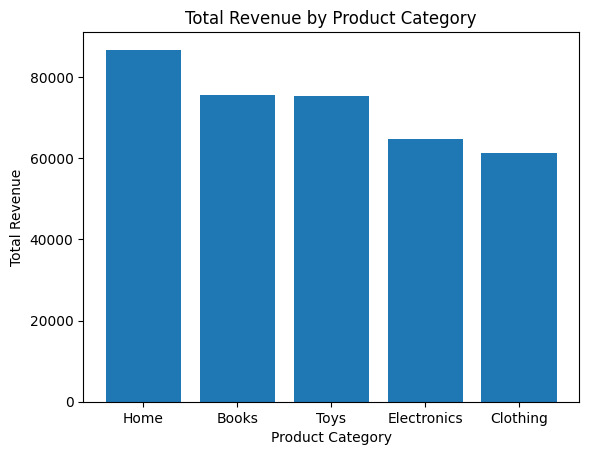

In [48]:
import matplotlib.pyplot as plt

plt.bar(sorted_revenue.index, sorted_revenue.values)
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Product Category')
plt.show()



# **Scatter Plot**
Correlation Analysis

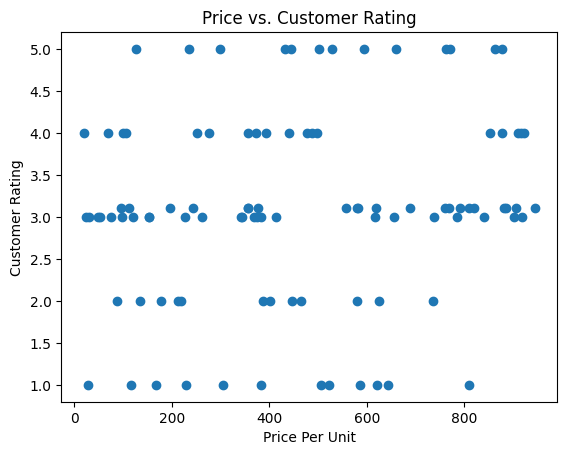

In [49]:
plt.scatter(df['Price_Per_Unit'], df['Customer_Rating'])
plt.xlabel('Price Per Unit')
plt.ylabel('Customer Rating')
plt.title('Price vs. Customer Rating')
plt.show()

# **Histogram**
Quantity Trends

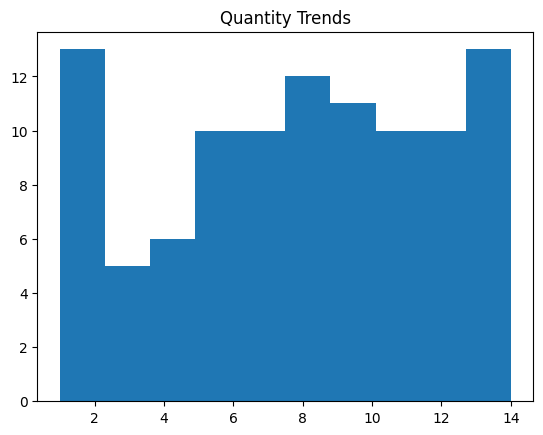

In [50]:
plt.hist(df['Quantity_Ordered'])
plt.title('Quantity Trends')
plt.show()

In [51]:
df.to_csv('final_sales_report.csv', index=False)